# **Prueba Práctica - NTT Data**

## **Use Case: Forecasting  de Precios**

- **Candidato**: Enzo Infantes Zúñiga 
- **Correo**: enzo.infantes28@gmail.com
- **LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

Una empresa de perfumería desea anticipar la evolución de precios de sus Eau de Parfum de 50ml para optimizar decisiones de inventario y planificación comercial. 

**Use Cases**: Lo trabajado en el notebook nos permitirá evaluar cinco Use que se pueden abordar con este dataset.

**1. UC1: Forecasting de precios de Eau de Parfum 50 ml**

- **Pregunta de negocio:** ¿Cómo evolucionarán los precios de mis Eau de Parfum de 50 ml en las próximas 4–8 semanas?
- **Target:** `price` semanal por producto (regresión).
- **Horizonte:** corto plazo (4-8 semanas).
- **Decisión que habilita:** planificación de inventario, fijación de precios competitivos, calendarios promocionales, anticipación de subidas de proveedor.
- **Stakeholders:** Pricing Manager, Category Manager, Supply Chain.
- **KPI:** MAPE por producto y RMSE en ventana OOT.

**2. UC2: Recomendación de precio inicial para un nuevo lanzamiento**

- **Pregunta de negocio:** Para una marca conocida que lanza un nuevo EdP 50 ml, ¿qué rango de precio inicial es competitivo y cuántas unidades cabe esperar las primeras semanas?
- **Target:** `price` y `units` esperadas (regresión sobre productos comparables).
- **Horizonte:** lanzamiento (semana 0) + 4 primeras semanas.
- **Decisión que habilita:** definir precio de salida y forecast de demanda inicial.
- **Stakeholders:** Marketing, Pricing, New Product Introduction.
- **KPI:** error sobre precio recomendado vs precio efectivo de productos comparables ya lanzados.

**3. UC3: Detección de productos en riesgo de quiebre de stock**

- **Pregunta de negocio:** ¿Qué productos van a romper stock en las próximas 2–4 semanas dado su ritmo de ventas y nivel de disponibilidad?
- **Target:** probabilidad de quiebre (clasificación binaria).
- **Variables clave:** `available_final`, `units` (rolling), `sold_value`, estacionalidad.
- **Decisión que habilita:** órdenes de reposición prioritarias.
- **KPI:** Recall en productos que efectivamente rompieron stock; F1.

**4. UC4: Segmentación de productos por dinámica precio-ventas**

- **Pregunta de negocio:** ¿Qué clústeres de productos existen según su elasticidad precio-ventas, volatilidad y estacionalidad?
- **Target:** etiquetas de clúster (no supervisado, pero alimenta modelos supervisados downstream).
- **Decisión que habilita:** estrategias diferenciadas (productos "premium estables", "promocionales", "long-tail", etc.).
- **KPI:** silhouette, estabilidad del clúster.

**5. UC5: Anomalías y errores de registro en precio**

- **Pregunta de negocio:** ¿Qué observaciones son atípicas (errores de medición, promociones agresivas, cambios de moneda) y deben revisarse antes de modelar?
- **Target:** flag de anomalía (clasificación o score).
- **Variables clave:** desviación respecto a la mediana del producto, separadores de miles, valores negativos.
- **Decisión que habilita:** mejorar la calidad del dato y reducir ruido en UC1/UC2.
- **KPI:** precision de detección verificada manualmente sobre una muestra.


# **1. Librerias**

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns
import re
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')

root_dir = os.path.dirname(os.getcwd())
raw_data = os.path.join(root_dir, 'data', 'raw')
processed_data = os.path.join(root_dir, 'data', 'processed')
output_dir = os.path.join(root_dir, 'output')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [42]:
def extract_available(text):
    '''
    La función `extract_available` toma un texto de disponibilidad y extrae dos valores:
    1. `available`: El número de unidades disponibles, que puede ser un número específico, 
       "Last One" (1 unidad), o "Out of Stock" (0 unidades). Si el formato es ambiguo, devuelve None.
    2. `sold`: El número de unidades vendidas, que se extrae si el texto contiene la palabra "sold". 
       Si no se encuentra, devuelve None.    
    '''
    if not isinstance(text, str):
        return None, None
    
    text = text.strip()
    
    # Extraer sold (número antes de " sold")
    sold_match = re.search(r'(\d+)\s+sold', text)
    sold = int(sold_match.group(1)) if sold_match else None

    # Sin stock
    if text.startswith("Out of Stock"):
        return 0, sold
    
    # Last One
    if text.startswith("Last One"):
        return 1, sold
    
    # N lots available/disponibles (M items per lot)
    match = re.match(r'^(\d+)\s+lots?\s+(?:available|disponible)\s*\((\d+)\s+items?\s+per\s+lot\)', text)
    if match:
        return int(match.group(1)) * int(match.group(2)), sold

    # N available / N disponibles
    match = re.match(r'^(\d+)\s+(?:available|disponible)', text)
    if match:
        return int(match.group(1)), sold

    # Ambiguos: None
    return None, sold

def clasificar_region(location):
    """Clasifica itemLocation en región principal"""
    if pd.isna(location):
        return 'Unknown'
    
    location = str(location).strip().lower()
    
    if 'hong kong' in location or 'hk' in location:
        return 'Hong Kong'
    elif 'china' in location or 'shenzhen' in location or 'shanghai' in location:
        return 'China'
    elif 'canada' in location or 'ontario' in location or 'toronto' in location:
        return 'Canada'
    elif 'japan' in location:
        return 'Japan'
    elif 'india' in location:
        return 'India'
    elif 'brazil' in location:
        return 'Brazil'
    elif 'united states' in location or 'usa' in location or any(x in location for x in ['texas', 'california', 'florida', 'new york', 'michigan']):
        return 'United States'
    else:
        return 'Other'
    

def clasificar_brand(brand):
    """Clasifica brand en categoría"""
    if pd.isna(brand):
        return 'Unknown'
    
    brand_str = str(brand).strip().lower()
    
    luxury = ['dior', 'tom ford', 'guerlain', 'creed', 'roja', 'frederic malle', 
              'jo malone', 'le labo', 'penhaligon', 'xerjoff', 'cartier', 'louis vuitton', 'hermes', 'prada']
    
    designer = ['chanel', 'versace', 'gucci', 'giorgio armani', 'paco rabanne', 
                'jean paul gaultier', 'givenchy', 'burberry', 'valentino', 'dolce', 'yves saint laurent', 'calvin klein']
    
    mass = ['unbranded', 'ariana grande', 'katy perry', 'taylor swift', 'britney spears', 
            'victoria secret', 'bath body works', 'hollister', 'abercrombie']
    
    if any(b in brand_str for b in luxury):
        return 'Luxury'
    elif any(b in brand_str for b in designer):
        return 'Designer'
    elif any(b in brand_str for b in mass):
        return 'Mass Market'
    else:
        return 'Mid-Range'
    
def extract_size_ml(title):
    """Extrae el tamaño del perfume en ml a partir del título.
    Convierte fl oz a ml (1 fl oz = 29.5735 ml).
    """
    if not isinstance(title, str):
        return np.nan
    t = title.lower()
    m = re.search(r'(\d+(?:\.\d+)?)\s*ml', t)
    if m:
        return float(m.group(1))
    m = re.search(r'(\d+(?:\.\d+)?)\s*(?:fl\s*\.?\s*)?oz', t)
    if m:
        return round(float(m.group(1)) * 29.5735, 1)
    return np.nan

def mape(y_true, y_pred):
    """Error porcentual absoluto medio (excluye ceros para evitar división por cero)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def forecast_recursivo(model, df_uc, features, fechas_oot, fecha_corte):
    """
    Genera el forecast de las semanas OOT sin usar datos futuros reales.
    - Parte del historial real hasta fecha_corte.
    - Cada predicción se añade al buffer para construir los lags de la semana siguiente.
    """
    resultados = []

    for prod_id, grupo in df_uc.groupby('product_id'):
        grupo = grupo.sort_values('fecha').reset_index(drop=True)
        hist  = grupo[grupo['fecha'] <= fecha_corte]

        if hist['price'].notna().sum() < 4:
            continue

        price_buf  = hist['price'].dropna().tolist()   # historial real de precios
        units_buf  = hist['units'].dropna().tolist()   # historial real de unidades
        precio_corte = price_buf[-1]  # último precio real conocido (fijo para el Naive)

        for fecha in fechas_oot:
            row = grupo[grupo['fecha'] == fecha]
            if row.empty:
                continue
            row = row.iloc[0].copy()

            # Lags construidos únicamente desde el buffer (real + predicciones previas del LGBM)
            row['price_lag_1'] = price_buf[-1]
            row['price_lag_2'] = price_buf[-2] if len(price_buf) >= 2 else price_buf[-1]
            row['price_lag_3'] = price_buf[-3] if len(price_buf) >= 3 else price_buf[-1]
            row['price_lag_4'] = price_buf[-4] if len(price_buf) >= 4 else price_buf[-1]
            last4 = price_buf[-4:]
            row['price_roll_mean_4'] = float(np.mean(last4))
            row['price_roll_std_4']  = float(np.std(last4)) if len(last4) >= 2 else 0.0
            row['units_lag_1']       = units_buf[-1] if units_buf else np.nan

            # Predicciones de los tres modelos con la misma información disponible
            pred_lgbm    = float(model.predict(pd.DataFrame([row[features]]),
                                               num_iteration=model.best_iteration)[0])
            # Naive: siempre el último precio REAL conocido antes del OOT (precio fijo)
            pred_naive   = precio_corte
            # Rolling: media de los últimos 4 valores del buffer (cambia con cada predicción LGBM)
            pred_rolling = float(np.mean(price_buf[-4:]))

            resultados.append({
                'product_id':   prod_id,
                'fecha':        fecha,
                'price_real':   row['price'],
                'pred_naive':   pred_naive,
                'pred_rolling': pred_rolling,
                'pred_lgbm':    pred_lgbm,
            })

            # Avanzar el buffer con la predicción del LGBM (no con el precio real)
            price_buf.append(pred_lgbm)
            units_buf.append(units_buf[-1] if units_buf else 0)

    return pd.DataFrame(resultados)


# **2. Carga Data**

In [43]:
df_raw = pd.read_csv(os.path.join(raw_data, 'Dataset_recruiting.csv'))

In [44]:
print(f'Shape: {df_raw.shape}')
date_cols = [c for c in df_raw.columns if re.fullmatch(r"\d{4}-\d{2}-\d{2}", str(c))] # date_cols = [c for c in df_raw.columns if c.startswith('20')]
print(f'Número de semanas: {len(date_cols)}  ({date_cols[0]} - {date_cols[-1]})')
df_raw.tail(1)

Shape: (4120, 37)
Número de semanas: 29  (2022-09-26 - 2023-04-10)


,brand,title,type,itemLocation,available,availableText,metric,2022-09-26,2022-10-03,2022-10-10,2022-10-17,2022-10-24,2022-10-31,2022-11-07,2022-11-14,2022-11-21,2022-11-28,2022-12-05,2022-12-12,2022-12-19,2022-12-26,2023-01-02,2023-01-09,2023-01-16,2023-01-23,2023-01-30,2023-02-06,2023-02-13,2023-02-20,2023-02-27,2023-03-06,2023-03-13,2023-03-20,2023-03-27,2023-04-03,2023-04-10,G
4119,Nina Ricci,Signoricci for Men by Nina Ricci EDT Splash1.7 fl oz New Sealed Box.Vintage.Rare,Eau de Toilette,"Argyle, Texas, United States",3.0,3 available / 172 sold,price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


# **3. EDA y Preprocesamiento**

**3.1. Estructura del Dataset**
- Cada producto aparece típicamente en 2 fílas, una para ver el su precio y la otra sus unidades.
- Las 29 columans de fecha contienen el valor semanal correspondiente a las métricas mencionadas.
- Pasamos a tener un registro por producto/fecha donde se tenga la columna price y units.

In [45]:
# 1. Definir columnas de ID (todas excepto las de fecha)
id_cols = [c for c in df_raw.columns if c not in date_cols]

# 2. Llenar NaN en brand, title, type, itemLocation usando forward/backward fill por grupo
key_cols = ['brand', 'title', 'type', 'itemLocation', 'availableText']
for col in key_cols:
    df_raw[col] = (df_raw.groupby(
        [c for c in key_cols if c != col], dropna=False
    )[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
    )

# 3. Transponer la tabla donde cada fila sea una observación del producto en el tiempo
df = df_raw.melt(id_vars=id_cols,
                 value_vars=date_cols,
                 var_name="fecha",
                 value_name="valor"
)

idx = [c for c in id_cols if c not in ("metric", "availableText", "available")] + ["fecha"]

df = df.pivot_table(index=idx, 
                    columns="metric", 
                    values="valor", 
                    aggfunc="first").reset_index()

df = df.sort_values(idx).reset_index(drop=True)

df.head(7)

metric,brand,title,type,itemLocation,G,fecha,price,units
0,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-09-26,32.99,NaN
1,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-10-03,33.95,NaN
2,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-10-10,32.99,NaN
3,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-10-17,32.99,NaN
4,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-10-24,33.95,NaN
5,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-10-31,32.99,NaN
6,0,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,Fragrances,"Hamtramck, Michigan, Estados Unidos",0,2022-11-07,"33,99",NaN


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58730 entries, 0 to 58729
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         58730 non-null  object
 1   title         58730 non-null  object
 2   type          58730 non-null  object
 3   itemLocation  58730 non-null  object
 4   G             58730 non-null  int64 
 5   fecha         58730 non-null  object
 6   price         54529 non-null  object
 7   units         55081 non-null  object
dtypes: int64(1), object(7)
memory usage: 3.6+ MB


**3.2. Formato Numérico de Precio y Unidades**
- Identificamos que el 4% de datos tiene como separador la ',' en el valor del precio y/o units.
- Asimismo, el 0.5% de los valores de las métricas son menores a cero. Hemos identificado que el valor absoluto del valor negativo se asemeja al valor promedio, o real, del producto.

In [47]:
cols = ["price", "units"]
n = len(df)

resumen = pd.DataFrame({
    "n_coma": df[cols].astype(str).apply(lambda s: s.str.contains(",", na=False)).sum(),
    "%_coma": (df[cols].astype(str).apply(lambda s: s.str.contains(",", na=False)).sum() / n * 100).round(2),
    "n_neg": df[cols].astype(str).apply(lambda s: s.str.contains("-", na=False)).sum(),
    "%_neg": (df[cols].astype(str).apply(lambda s: s.str.contains("-", na=False)).sum() / n * 100).round(2),
})

display(resumen)

mask = (df["price"].astype(str).str.contains(",", na=False) | df["units"].astype(str).str.contains(",", na=False))
df.loc[mask, ["price","units"]].head(10)

,n_coma,%_coma,n_neg,%_neg
metric,,,,
price,2665,4.54,258,0.44
units,2637,4.49,258,0.44


metric,price,units
6,"33,99",NaN
19,"32,99",NaN
20,"32,99",NaN
38,51.99,"137,0"
45,"5,299",88.0
79,"6,407181",35.0
96,6.488099999999999,"279,0"
107,5.553106688480571,"349,0"
110,"6,047333183755342",NaN
114,"7,2479",200.0


In [48]:
# 1. Reemplazar ',' por '.' 
df[cols] = df[cols].replace({',': '.'}, regex=True)

# 2. Valores negativos
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df[cols] = df[cols].applymap(lambda x: abs(x) if (x < 0) & pd.notnull(x) else x)

# 3. Revisar los casos con formato incorrecto
df.loc[[6, 19, 20, 96, 107], ["price","units"]]

metric,price,units
6,33.990000,NaN
19,32.990000,NaN
20,32.990000,NaN
96,6.488100,279.0
107,5.553107,349.0


**3.4. Variable Available y AvailableText**

- Esta variable presenta ciertas casuísticas que podrían afectar el análisis. Ejemplo `Armaf Club De Nuit Intense 5.07oz` avariable 10 y -10 (df_raw[df_raw['title'].str.contains('Armaf Club De Nuit Intense 5.07oz ', na=False)].head()).
- Presenta valores negativos de disponibilidad para una métrica; sin embargo, para la otra presenta el mismo valor pero en positivo.
- Asimismo, a partir del AvailableText se puede inferir la disponibilidad del producto a pesar de que en la columna Available figure como nulo.
- Hay valores comprobables que siguen siendo altos. El único caso atípico resulta el de  `Giorgio Armani Acqua Di Gio 3.4 oz Men\'s Eau De Toilette Spray Brand New`.

In [49]:
# 1. Extraer available_value y sold_value de availableText
df_raw[['available_value', 'sold_value']] = df_raw['availableText'].apply(lambda x: pd.Series(extract_available(x)))

# 2. Productos donde available_value es None, calcular el mínimo de available (conservador)
df_raw['available_fallback'] = df_raw.groupby(['brand', 'title', 'type', 'itemLocation'])['available'].transform(lambda x: x.abs().min())
df_raw['available_final'] = df_raw['available_value'].fillna(df_raw['available_fallback'])

# 3. Unificar por producto, tomar la primera fila,
df_raw_unified = (df_raw
    .sort_values('available_value', na_position='last')
    .drop_duplicates(subset=['brand', 'title', 'type', 'itemLocation'], keep='first')
)

# 4. Traer info al dataframe pivotado
info_extra = df_raw_unified[["brand", "title", "type", "itemLocation", 
                              "availableText", "available_final", "sold_value"]].copy()

df = df.merge(info_extra, 
              on=["brand", "title", "type", "itemLocation"], 
              how="left")

**3.5. Distribución de las variables numéricas**
- Se observa presencia de valores extremos positivos en la distribución delas variables númericas.
- Hay casos como el de `Women Perfume 3.4 oz / 100 ml Eau De Toilette Spray` que solo en dos semanas registran un valor extremadamente alto respecto a su media histórica del precio (36 -> 359.9 o 366.201). Posible Error de Medición.

array([[<Axes: title={'center': 'G'}>, <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'units'}>,
        <Axes: title={'center': 'available_final'}>],
       [<Axes: title={'center': 'sold_value'}>, <Axes: >]], dtype=object)

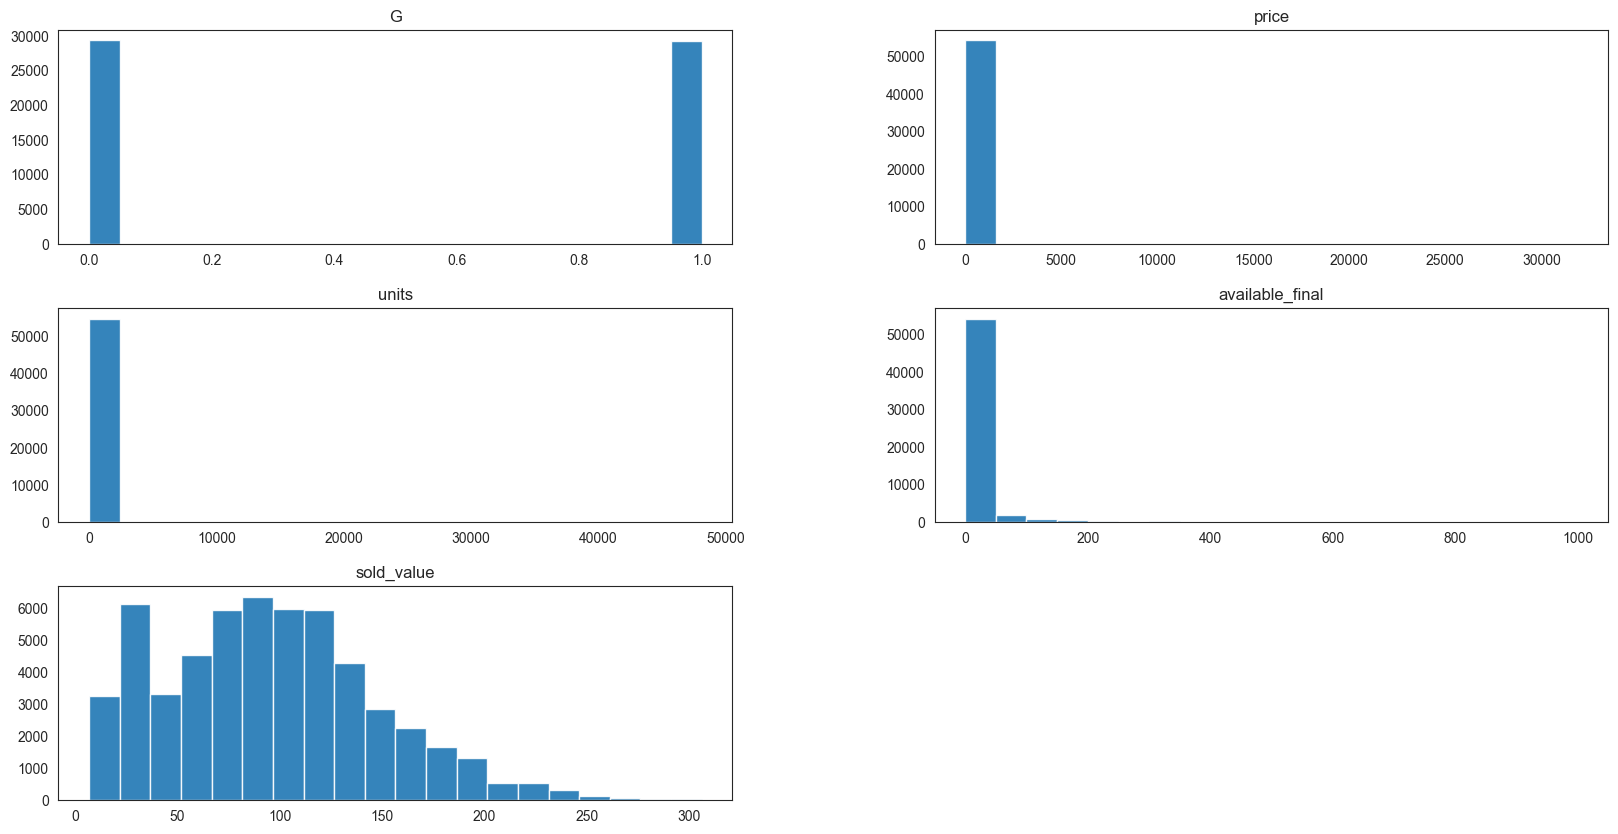

In [50]:
df.hist(bins=20, figsize=(20,10), alpha=0.9, grid=False)

In [51]:
df.select_dtypes(include='number').quantile(0.99)

G                    1.0000
price              208.3212
units              448.0000
available_final    252.0000
sold_value         232.0000
Name: 0.99, dtype: float64

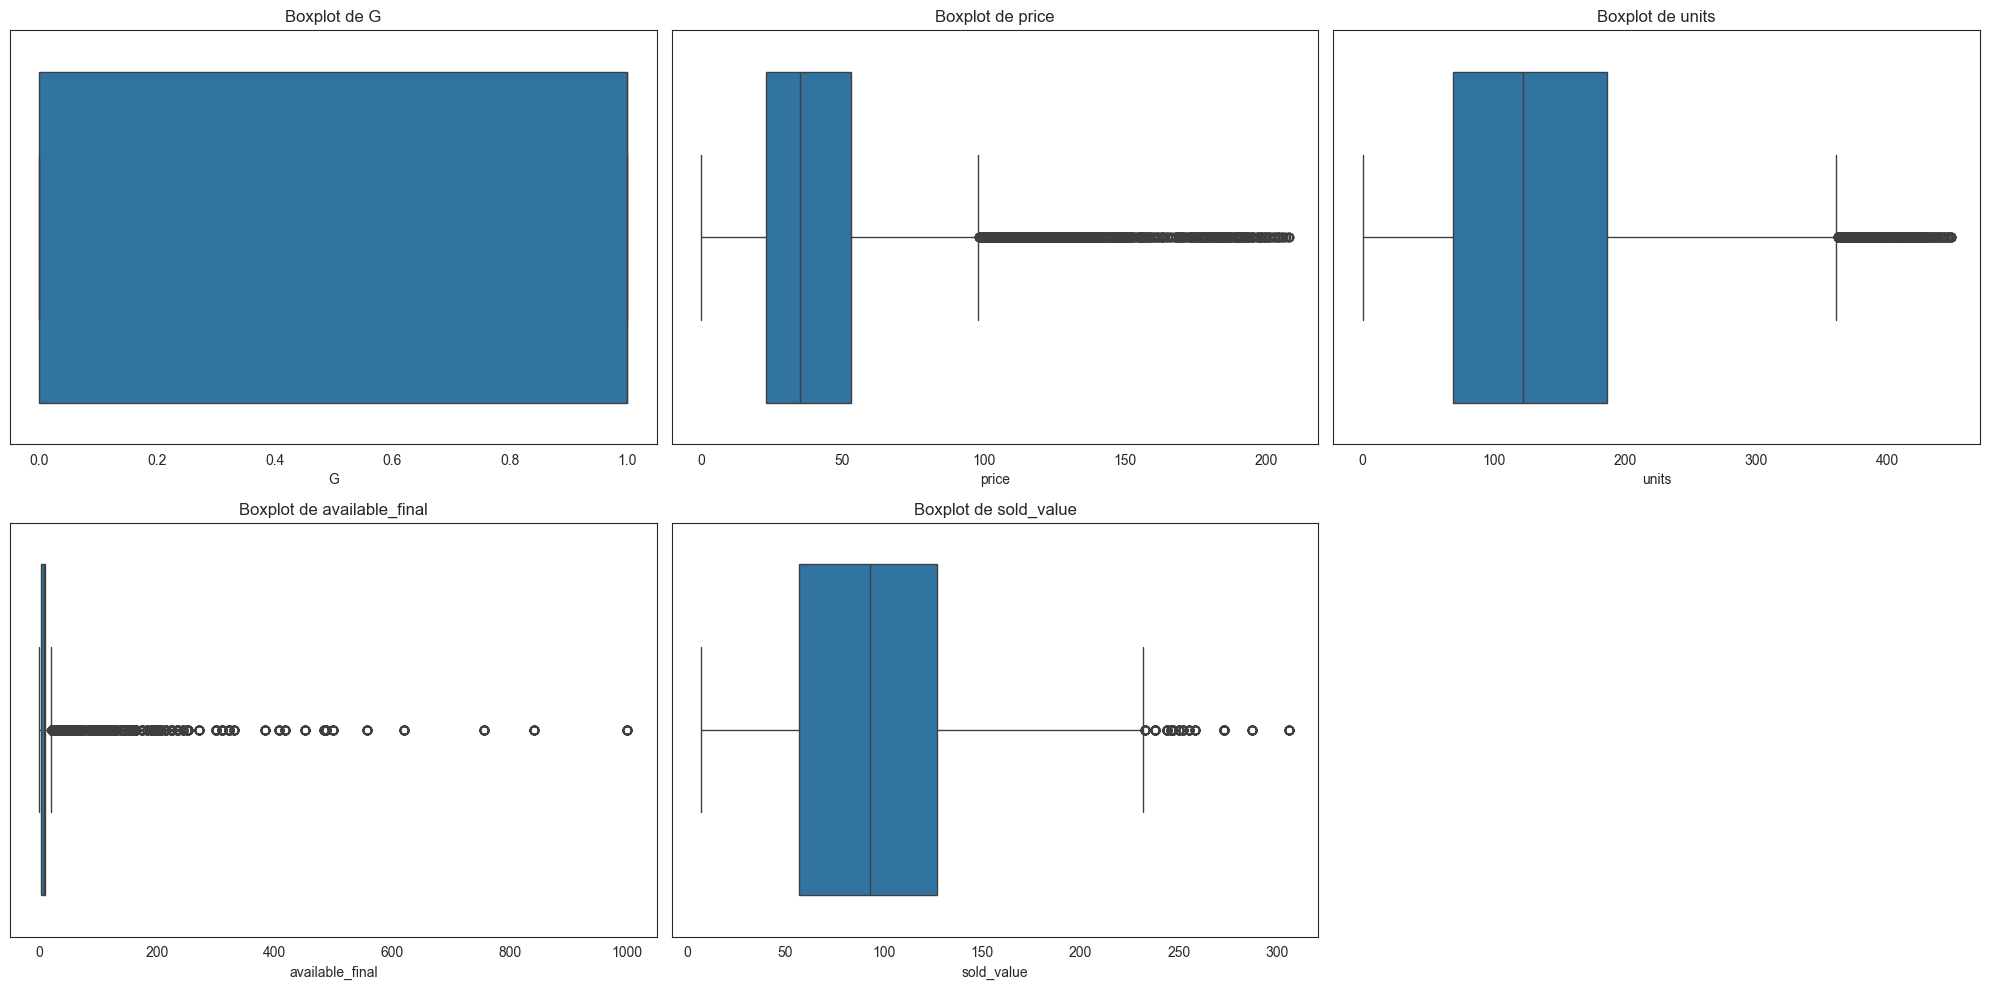

In [52]:
q_price = df['price'].quantile(0.99)
q_units = df['units'].quantile(0.99)

df_p99 = df[(df['price'] <= q_price) & (df['units'] <= q_units)].copy()

v_num = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes_flat = axes.flatten()

for col, ax in zip(v_num, axes.flatten()[:len(v_num)]):
    sns.boxplot(data=df_p99, x=col, ax=ax)
    ax.set_title(f'Boxplot de {col}')
    ax.grid(False)
  
for j in range(len(v_num), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

**3.6. Missing Values**

- Observamos un porcentaje importante de valores ausentes en `price` y `units (11%)
- Debido a la naturaleza del problema, y despues de revisar una serie de casos, la mejor técnica de imputación es tomar el último valor registrado o el valor inmediato.
- El resto de variables imputamos la mediana del grupo, marca, tipo o global.


In [53]:
df.isnull().mean().to_frame(name='missing_pct').sort_values('missing_pct', ascending=False).T

,price,units,sold_value,availableText,available_final,brand,title,type,fecha,itemLocation,G
missing_pct,0.071531,0.062132,0.05435,0.023327,0.003405,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
fechas = sorted(df['fecha'].unique())
n_oot = 4   # últimas 4 semanas → OOT
fechas_oot   = fechas[-n_oot:]
fechas_oot = pd.to_datetime(fechas_oot)

mask_no_oot = ~df['fecha'].isin(fechas_oot)

In [55]:
# 1. Ordemar por producto y fecha
keys = ['brand', 'title', 'type', 'itemLocation']
df = df.sort_values(keys + ['fecha'])
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values(keys + ['fecha'])

# 2. Imputar ffill + bfill POR PRODUCTO (antes del split)
df.loc[mask_no_oot, 'price'] = (
    df.loc[mask_no_oot]
      .groupby(keys)['price']
      .transform(lambda s: s.ffill().bfill())
)
      
df.loc[mask_no_oot, 'units'] = (
    df.loc[mask_no_oot]
      .groupby(keys)['units']
      .transform(lambda s: s.ffill().bfill())
)

# 3. Productos sin información en el precio y unit 
df = df.groupby(keys).filter(lambda x: x['price'].notna().any() & x['units'].notna().any()).reset_index(drop=True)

In [56]:
df.isnull().mean().to_frame(name='missing_pct').sort_values('missing_pct', ascending=False).T

,sold_value,availableText,available_final,type,title,brand,itemLocation,price,fecha,G,units
missing_pct,0.038347,0.009861,0.001096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
# 1. Mediana por marca y tipo para sold_value
#    En caso no encuentre, por la mediana global (<1%)
df['sold_value'] = df.groupby(['brand','type'])['sold_value'].transform(lambda s: s.fillna(s.median()))
df['sold_value'] = df['sold_value'].fillna(df['sold_value'].median()) 

# 2. Mediana por marca y tipo para available_final (median)
df['available_final'] = df.groupby(['brand','type'])['available_final'].transform(lambda x: x.fillna(x.median()))

**3.7. Outliers**
- Las variables price y units presentaban una distribución con valores extremos positivos.
- Debido a la baja materialidad se excluirá del análisis el p99 en cada caso.

In [58]:
q_price = df['price'].quantile(0.99)
q_units = df['units'].quantile(0.99)

df_clean = df[(df['price'] <= q_price) & (df['units'] <= q_units)].copy()
print(f'Número de filas finales: {len(df_clean)}')
print(f'Porcentaje de filas eliminadas: {round((len(df) - len(df_clean)) / len(df) * 100, 2)}%')

Número de filas finales: 51889
Porcentaje de filas eliminadas: 1.98%


**3.8. Análisis Univariado**

- Las categorias más comunes son:
	- brand: Mid-Range
	- region: United States
	- type: Eau de Parfum
	- G: 50.21% para hombres

- Las distribuciones de las variables continuas estan más acotadas a valores centrales.

In [59]:
df_clean['region'] = df_clean['itemLocation'].apply(clasificar_region)
df_clean['brand_category'] = df_clean['brand'].apply(clasificar_brand)

In [60]:
df_clean.describe(include='all')

,brand,title,type,itemLocation,G,fecha,price,units,availableText,available_final,sold_value,region,brand_category
count,51889,51889,51889,51889,51889.000000,51889,51889.000000,51889.000000,51373,51889.000000,51889.000000,51889,51889
unique,380,1777,5,417,NaN,NaN,NaN,NaN,1158,NaN,NaN,8,4
top,Giorgio Armani,YSL Yves Saint Laurent Y Eau de Perfume Spray Cologne For Men 3.3 oz 100ML,Eau de Parfum,"Dallas, Texas, United States",NaN,NaN,NaN,NaN,Ships immediately,NaN,NaN,United States,Mid-Range
freq,1896,114,23200,6763,NaN,NaN,NaN,NaN,577,NaN,NaN,47590,33133
mean,NaN,NaN,NaN,NaN,0.502149,2023-01-02 00:20:12.187554048,42.629700,134.729667,NaN,19.095756,94.043256,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,2022-09-26 00:00:00,0.000000,0.000000,NaN,0.000000,7.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.000000,2022-11-14 00:00:00,22.760100,69.000000,NaN,3.000000,55.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,2023-01-02 00:00:00,34.990000,122.000000,NaN,9.000000,92.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,1.000000,2023-02-20 00:00:00,52.990000,186.000000,NaN,10.000000,125.000000,NaN,NaN
max,NaN,NaN,NaN,NaN,1.000000,2023-04-10 00:00:00,211.990000,447.000000,NaN,1000.000000,306.000000,NaN,NaN


array([[<Axes: title={'center': 'G'}>, <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'units'}>,
        <Axes: title={'center': 'available_final'}>],
       [<Axes: title={'center': 'sold_value'}>, <Axes: >]], dtype=object)

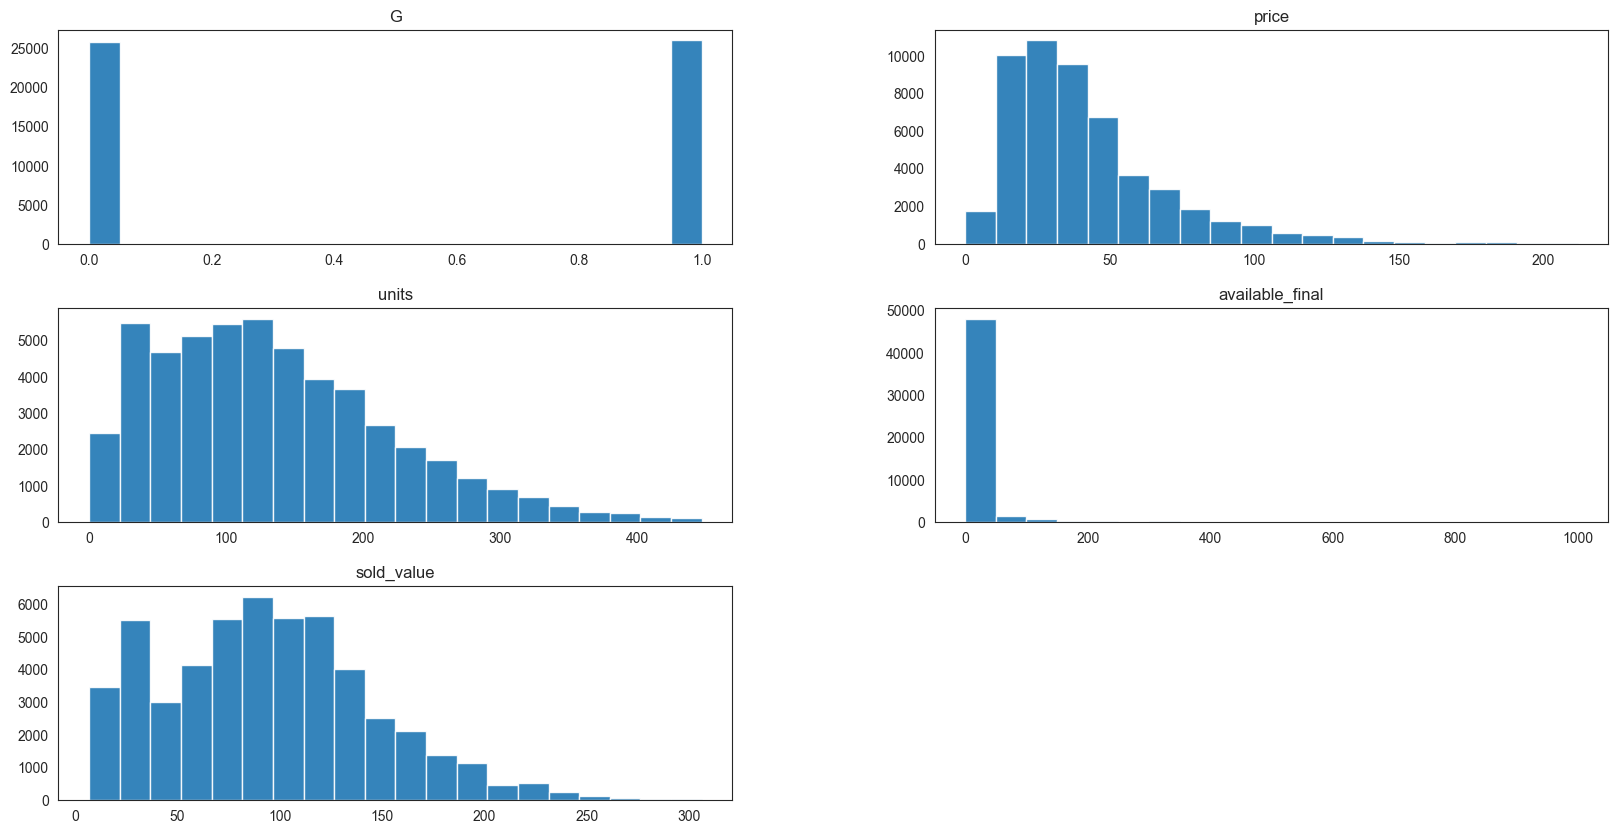

In [61]:
v_num = df_clean.select_dtypes(include='number').columns.tolist()
df_clean[v_num].hist(bins=20, figsize=(20,10), alpha=0.9, grid=False)

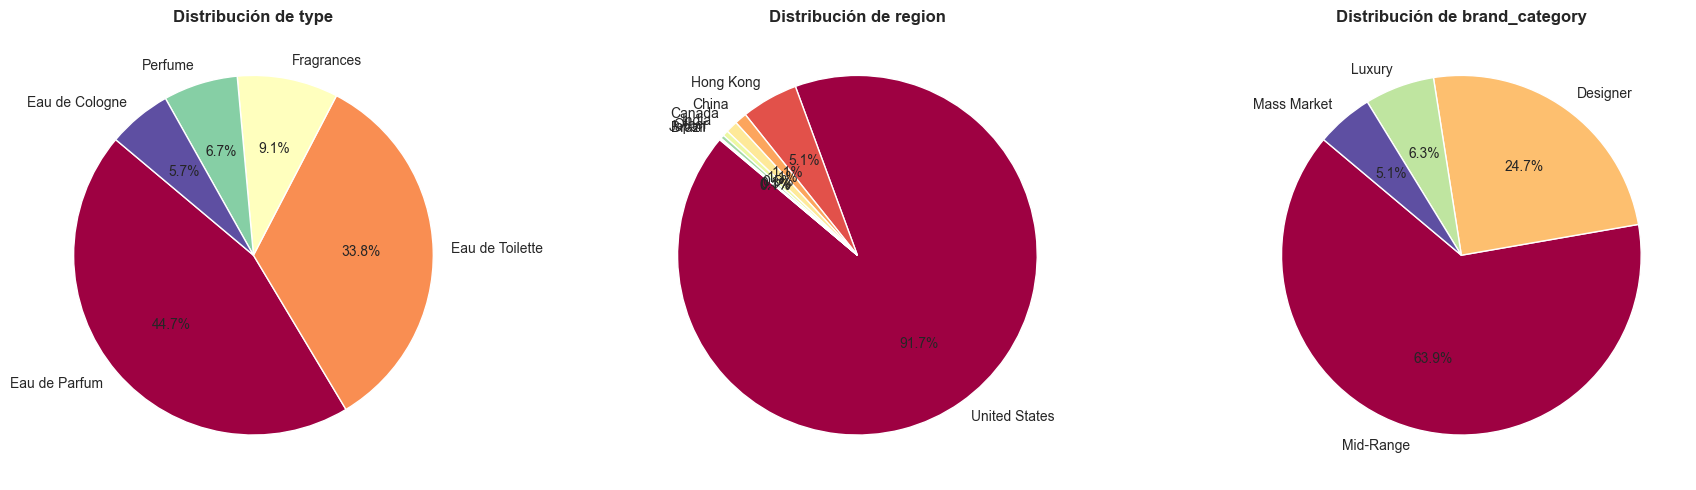

In [62]:
v_cat = ['type', 'region', 'brand_category']

n_cols = 3
n_rows = (len(v_cat) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(v_cat):
    data_counts = df_clean[col].value_counts()
    
    axes[i].pie(
        data_counts, 
        labels=data_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Spectral(np.linspace(0, 1, len(data_counts))),
        wedgeprops={'edgecolor': 'white'}
    )
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**3.9. Análisis Bivariado**
- Observamos que los perfumes Eau de Parfum tienen un precio promedio mayor. Al igual que los que se han vendido en Brazil (solo un producto) o pertenecen a la categoría de luxury.
- A nivel de precios y unidades vendidas, los perfumes Eau de Parfum tienen una mediana más elevada que el resto y mayor concentración de valores altos en su distribución.
- En el mes de marzo se ve un alza relevante en el precio promedio de los perfumes.
- Las cantidades vendidas son mayores a cierres de año.

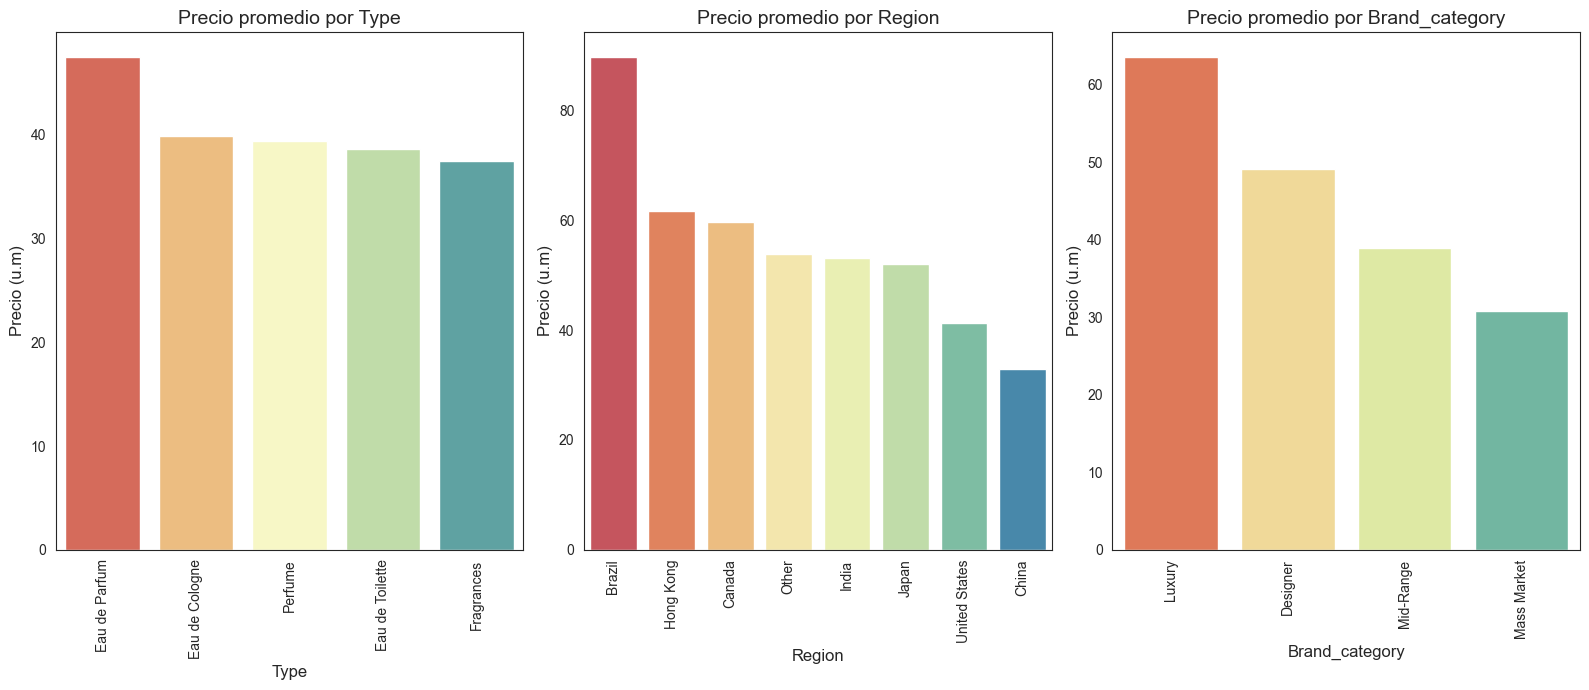

In [63]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 7))

for col, ax in zip(v_cat, axes.flatten()): 
    price = df_clean.groupby(col)['price'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=price, x=col, y='price', ax=ax, palette="Spectral")
    ax.set_title(f'Precio promedio por {col.capitalize()}', fontsize=14)
    ax.set_xlabel(col.capitalize(), fontsize=12)
    ax.set_ylabel("Precio (u.m)", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(False)
plt.tight_layout()
plt.show()

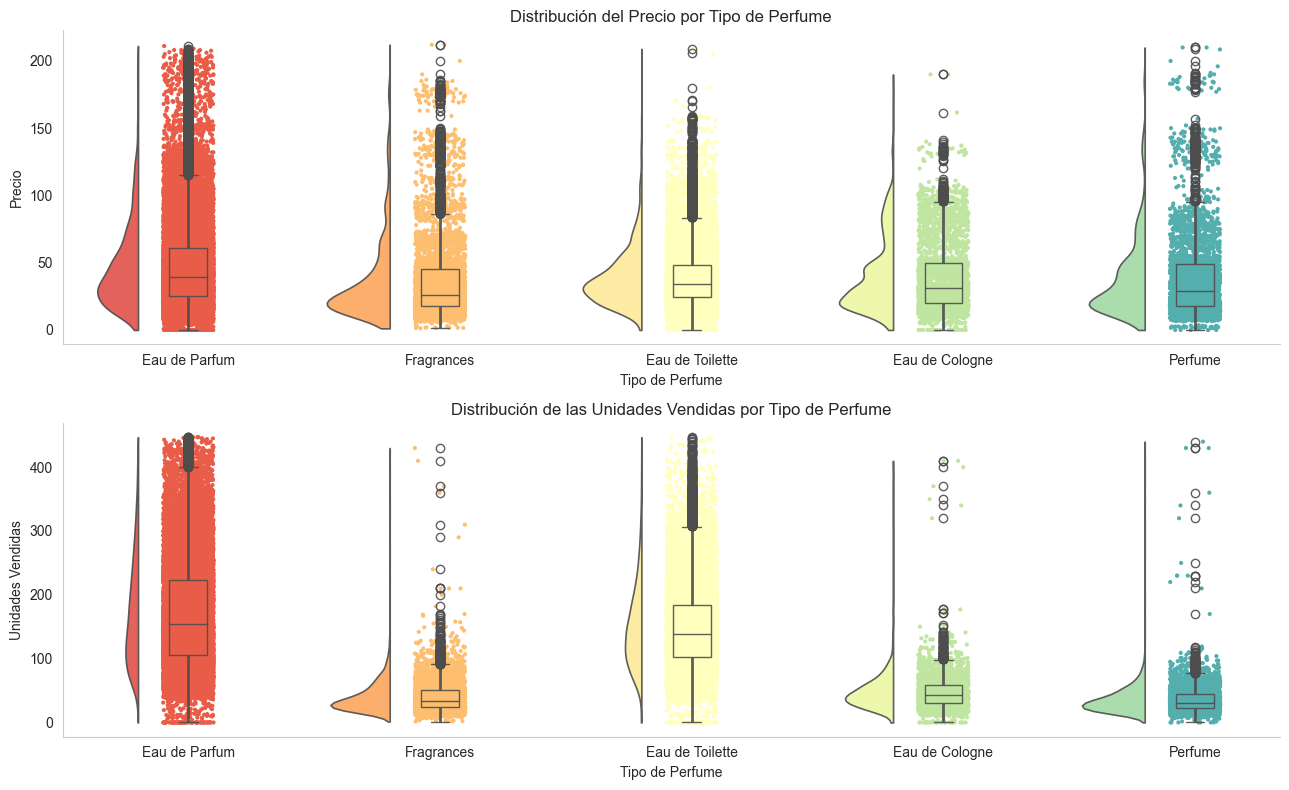

In [64]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

pt.RainCloud(x="type", y="price", data=df_clean,
                palette='Spectral', bw=0.2, width_viol=0.5, ax=axes[0],
                alpha=0.9, jitter=True, linewidth=1.2) 
axes[0].set_title("Distribución del Precio por Tipo de Perfume", fontsize=12)
axes[0].set_xlabel("Tipo de Perfume", fontsize=10)
axes[0].set_ylabel("Precio", fontsize=10)
axes[0].grid(False)
sns.despine(ax=axes[0])
plt.grid(False)

pt.RainCloud(x="type", y="units", data=df_clean,
                palette='Spectral', bw=0.2, width_viol=0.5, ax=axes[1],
                alpha=0.9, jitter=True, linewidth=1.2)
axes[1].set_title("Distribución de las Unidades Vendidas por Tipo de Perfume", fontsize=12)
axes[1].set_xlabel("Tipo de Perfume", fontsize=10)
axes[1].set_ylabel("Unidades Vendidas", fontsize=10)
axes[1].grid(False)
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

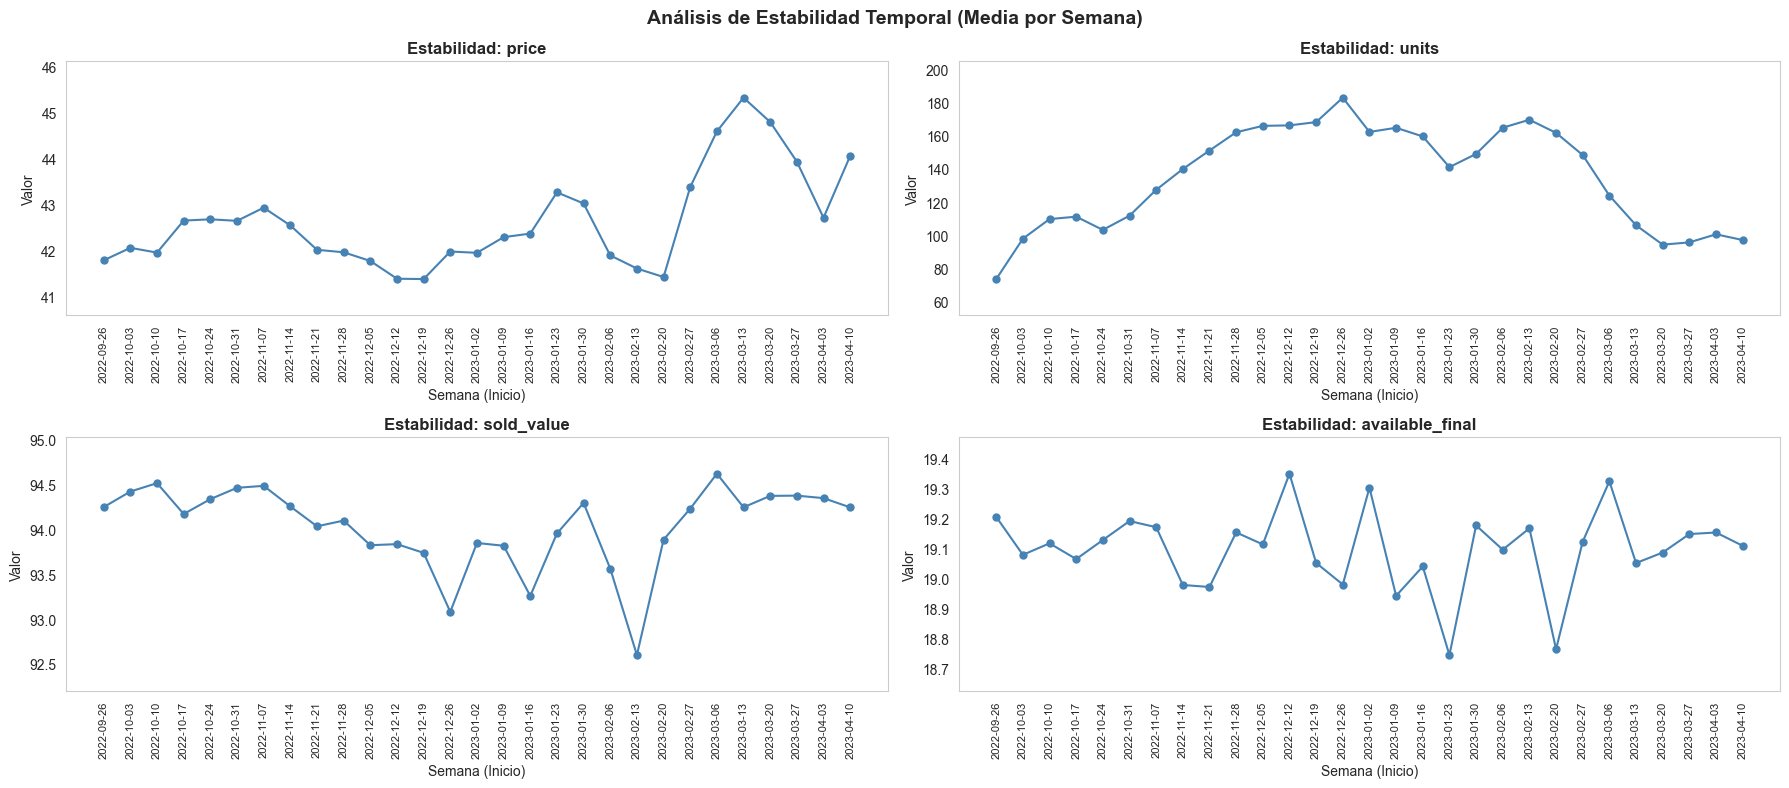

In [65]:
df_clean['week'] = df_clean['fecha'].dt.to_period('W')
df_clean['week_str'] = df_clean['week'].astype(str)
df_clean.drop(columns=['week'], inplace=True)

variables = ['price', 'units', 'sold_value', 'available_final']

weekly_data = df_clean.groupby('week_str')[variables].mean()

ncols = 2
nrows = (len(variables) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]
    
    values = weekly_data[col].values
    weeks = range(len(values))
    
    ax.plot(weeks, values, marker='o', markersize=5, 
            linewidth=1.5, color='steelblue')
    
    y_min, y_max = values.min(), values.max()
    margin = (y_max - y_min) * 0.2
    ax.set_ylim(y_min - margin, y_max + margin)
    
    ax.set_title(f'Estabilidad: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Semana (Inicio)', fontsize=10)
    ax.set_ylabel('Valor', fontsize=10)
    ax.grid(False)
    
    # Mostrar solo la fecha de inicio (primer 10 caracteres: YYYY-MM-DD)
    tick_positions = range(len(weekly_data))
    tick_labels = [label[:10] for label in weekly_data.index.tolist()]
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Análisis de Estabilidad Temporal (Media por Semana)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**3.10. Análisis Multivariado**
- La matriz de correlación nos advierte una relación entre el precio y las unidades disponibles.
- Asimismo, la unidades vendidas con lo reportado en sold_value guardan mucha relación.

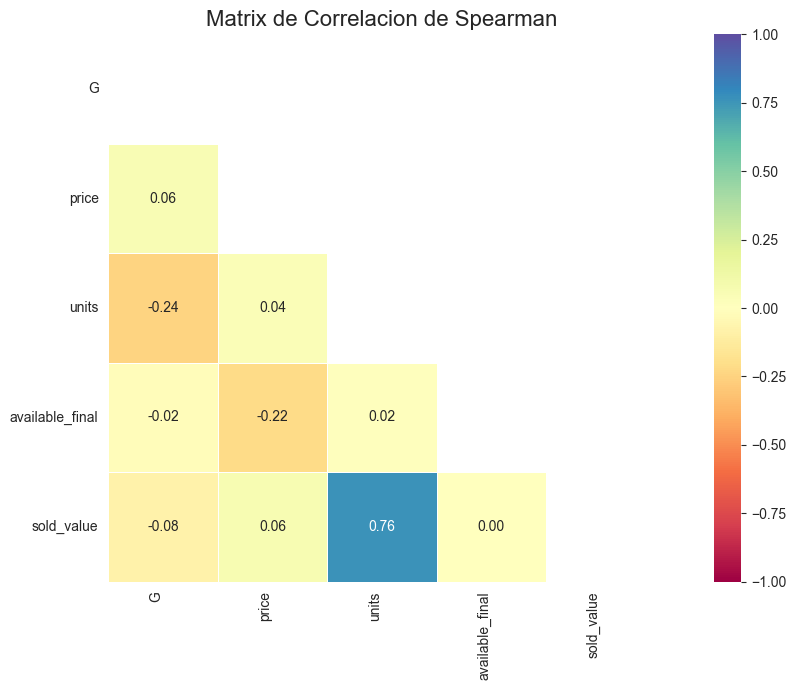

In [66]:
corr = df_clean[v_num].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 7))
sns.set_style("white")  

sns.heatmap(corr, mask=mask, cmap="Spectral", 
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 10}, linewidths=0.5, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matrix de Correlacion de Spearman", fontsize=16)
plt.tight_layout()
plt.show()

In [67]:
df_clean.to_csv(os.path.join(processed_data, 'Dataset_Cleaned.csv'), index=False)

# **4. Feature Engineering**

| Bloque | Variables creadas | Justificación |
|---|---|---|
| Título | `size_ml`, `is_gift_set`, `is_tester`, `is_new_sealed`, `is_vintage`, `is_spray` | Capturan formato y presentación del producto, no presentes en otras columnas. |
| Geo | `is_us` | 91% del dataset es US; usar dummy evita ruido por one-hot disperso. |
| Calendario | `week_num`, `month`, `quarter`, `is_holiday_season`, `is_valentine` | Estacionalidad típica del retail de perfumería. |
| Producto | `product_id_code` | Permite a LightGBM aprender efecto fijo por producto sin one-hot encoding. |
| Temporales | `price_lag_{1,2,4}`, `price_roll_mean_4`, `price_roll_std_4`, `units_lag_1`, `units_roll_mean_4` | Memoria reciente; volatilidad como proxy de incertidumbre. |

Se **excluye** `sold_value` del modelo final por su alta correlación con `units` ya identificada en el EDA, manteniendo `units_lag_1` como representante.

**6.1. Variables derivadas del título**

El campo `title` contiene información estructurada que no está capturada en otras columnas: tamaño en ml, indicadores de presentación (set, tester, vintage), etc. Las extraemos con expresiones regulares para enriquecer el modelo.


In [68]:
df_clean['size_ml'] = df_clean['title'].apply(extract_size_ml)

# Indicadores binarios desde título
title_lower = df_clean['title'].str.lower().fillna('')
df_clean['is_gift_set']   = title_lower.str.contains(r'gift\s*set|set|kit',  regex=True).astype(int)
df_clean['is_tester']     = title_lower.str.contains(r'tester',               regex=True).astype(int)
df_clean['is_new_sealed'] = title_lower.str.contains(r'new\s*sealed|sealed|brand\s*new', regex=True).astype(int)
df_clean['is_vintage']    = title_lower.str.contains(r'vintage|rare',         regex=True).astype(int)
df_clean['is_spray']      = title_lower.str.contains(r'spray',                regex=True).astype(int)

print(f"size_ml extraído: {df_clean['size_ml'].notna().mean()*100:.1f}% de las filas")
df_clean[['title','size_ml','is_gift_set','is_tester','is_new_sealed','is_vintage']].head(5)

size_ml extraído: 95.0% de las filas


,title,size_ml,is_gift_set,is_tester,is_new_sealed,is_vintage
0,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,100.5,0,0,0,0
1,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,100.5,0,0,0,0
2,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,100.5,0,0,0,0
3,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,100.5,0,0,0,0
4,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,100.5,0,0,0,0


**6.2. Variables de contexto: región, calendario y producto**

- `is_us`: ~91% del dataset es US, lo dicotomizamos para no inflar la dimensionalidad.
- Calendario: mes, semana ISO y banderas de **temporada navideña** (Nov-Dic) y **San Valentín** (Feb), donde el negocio de perfumería suele tener picos.
- `product_id`: identificador único producto (brand+title+type+itemLocation). Se codifica para LightGBM como categórica nativa.

In [69]:
# 1. Región US vs Resto
df_clean['is_us'] = (df_clean['region'] == 'United States').astype(int)

# 2. Calendario
df_clean['fecha']             = pd.to_datetime(df_clean['fecha'])
df_clean['week_num']          = df_clean['fecha'].dt.isocalendar().week.astype(int)
df_clean['month']             = df_clean['fecha'].dt.month
df_clean['quarter']           = df_clean['fecha'].dt.quarter
df_clean['is_holiday_season'] = df_clean['month'].isin([11, 12]).astype(int)
df_clean['is_valentine']      = (df_clean['month'] == 2).astype(int)

# 3. Product id
df_clean['product_id'] = (df_clean['brand'].astype(str) + '|' +
                          df_clean['title'].astype(str) + '|' +
                          df_clean['type'].astype(str)  + '|' +
                          df_clean['itemLocation'].astype(str))
df_clean['product_id_code'] = df_clean['product_id'].astype('category').cat.codes

print(f"Productos únicos en el dataset limpio: {df_clean['product_id'].nunique()}")

Productos únicos en el dataset limpio: 1820


**6.3. Filtro al universo del UC: Eau de Parfum cercano a 50 ml**

- El UC pide modelar **Eau de Parfum de 50 ml** ya existentes. 
- Aplicamos un filtro pragmático: `type == "Eau de Parfum"` y `size_ml ∈ [40, 60]`. La banda alrededor de 50 ml absorbe el redondeo de la conversión desde fl oz (e.g. 1.7 fl oz ≈ 50.3 ml).

In [70]:
df_uc = df_clean[
    (df_clean['type'] == 'Eau de Parfum') &
    (df_clean['size_ml'].between(40, 60))
].copy()

print(f"Subset UC (EdP 50 ml ±10): {df_uc.shape[0]} obs, {df_uc['product_id'].nunique()} productos")
print(f"Cobertura temporal: {df_uc['fecha'].min().date()} a {df_uc['fecha'].max().date()}")

Subset UC (EdP 50 ml ±10): 2018 obs, 71 productos
Cobertura temporal: 2022-09-26 a 2023-04-10


**6.4. Features de lag y rolling**

- Son el corazón de un forecast: el precio de la semana anterior y promedios móviles. 
- **Importante**: se construyen *por producto* y con `shift(1)` antes del rolling para evitar fuga temporal (no usamos información del mismo periodo).

In [71]:
df_uc = df_uc.sort_values(['product_id', 'fecha']).reset_index(drop=True)

# 1. Lags de precio
for lag in [1, 2, 3, 4]:
    df_uc[f'price_lag_{lag}'] = df_uc.groupby('product_id')['price'].shift(lag)

# 2. Rolling 4 semanas, calculado sobre el shift(1) para no incluir la semana actual
df_uc['price_roll_mean_4'] = (df_uc.groupby('product_id')['price']
                              .shift(1).rolling(4).mean().reset_index(0, drop=True))
df_uc['price_roll_std_4']  = (df_uc.groupby('product_id')['price']
                              .shift(1).rolling(4).std().reset_index(0, drop=True))

# 3. Demanda (units) como feature exógena
df_uc['units_lag_1']        = df_uc.groupby('product_id')['units'].shift(1)
df_uc['units_roll_mean_4']  = (df_uc.groupby('product_id')['units']
                                .shift(1).rolling(4).mean().reset_index(0, drop=True))

print(f"Dataset con features: {df_uc.shape}")
df_uc.filter(regex='price|units|fecha|product_id$').head(5)

Dataset con features: (2018, 36)


,fecha,price,units,product_id,price_lag_1,price_lag_2,price_lag_3,price_lag_4,price_roll_mean_4,price_roll_std_4,units_lag_1,units_roll_mean_4
0,2022-09-26,8.99,92.0,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-10-03,8.90,123.0,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",8.99,NaN,NaN,NaN,NaN,NaN,92.0,NaN
2,2022-10-10,8.99,132.0,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",8.90,8.99,NaN,NaN,NaN,NaN,123.0,NaN
3,2022-10-17,8.95,129.0,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",8.99,8.90,8.99,NaN,NaN,NaN,132.0,NaN
4,2022-10-24,8.99,149.0,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",8.95,8.99,8.90,8.99,8.9575,0.04272,129.0,119.0


# **5. Modelamiento**

**El problema central**: Tienes el precio de cada perfume semana a semana durante 29 semanas y queremos predecir cuánto va a costar en las próximas semanas (OOT).

- **Baseline Naive**: El precio de la próxima semana va a ser igual al de esta semana.
- **Rolling Mean**: El precio se aproxima como el promedio de las últimas 4 semanas.
- **LightGBM**: Modelo ML para predecir la semana siguiente, sabiendo el precio real de la semana anterior. Luego se realiza un forecast recursivo para el periodo OOT.

```
|------ TRAIN (20 sem) ------|--- VAL (4 sem) ---|-- OOT (4 sem) --|
    S1  S2  S3 ... S21          S22 S23 S24 S25    S26 S27 S28 S29
```

In [72]:
# El orden temporal debe respetarse: NO se puede mezclar train con oot.
# - Train:  el modelo aprende con estos datos
# - Val:    sirve para el early stopping del LightGBM (no entra en el aprendizaje)
# - OOT:    simula "el futuro real", es la métrica de evaluación final

fechas = sorted(df_uc['fecha'].unique())

n_oot = 4   # últimas 4 semanas → periodo a pronosticar
n_val = 4   # 4 semanas anteriores → validación del LightGBM

fechas_oot   = fechas[-n_oot:]
fechas_val   = fechas[-(n_oot + n_val):-n_oot]
fechas_train = fechas[:-(n_oot + n_val)]

df_uc['split'] = np.where(df_uc['fecha'].isin(fechas_train), 'train',
                  np.where(df_uc['fecha'].isin(fechas_val),   'val', 'oot'))

# Último día conocido antes del OOT
fecha_corte = max(fechas_val)

print(f"Train : {len(fechas_train)} sem  ({fechas_train[0].date()} - {fechas_train[-1].date()})")
print(f"Val   : {len(fechas_val)} sem  ({fechas_val[0].date()} - {fechas_val[-1].date()})")
print(f"OOT   : {len(fechas_oot)} sem  ({fechas_oot[0].date()} - {fechas_oot[-1].date()})")
print(f"\nÚltimo precio conocido antes del OOT: semana del {fecha_corte.date()}")

Train : 21 sem  (2022-09-26 - 2023-02-13)
Val   : 4 sem  (2023-02-20 - 2023-03-13)
OOT   : 4 sem  (2023-03-20 - 2023-04-10)

Último precio conocido antes del OOT: semana del 2023-03-13


In [73]:
# Eliminar filas con lags NaN (primeras semanas de cada producto)
df_train_val = df_uc[df_uc['split'].isin(['train', 'val'])].dropna(
    subset=['price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_4', 'price_roll_mean_4']
).copy()

print(f"Filas train/val: {len(df_train_val)}")
print(df_train_val['split'].value_counts())

Filas train/val: 1454
split
train    1172
val       282
Name: count, dtype: int64


**5.1. Baseline 1: Naive lag-1**
- La predicción es simplemente el precio de la semana anterior.
- No usa ningún modelo, solo una regla: "el precio no cambia".

In [74]:
df_train_val['pred_naive']   = df_train_val['price_lag_1']

**5.2. Baseline 2: Rolling Mean (4 semanas)**
- La predicción es el promedio de los últimos 4 precios observados.
- Ya calculamos price_roll_mean_4 en el Feature Engineering (shift(1) + rolling(4)).

In [75]:
df_train_val['pred_rolling'] = df_train_val['price_roll_mean_4']

**5.3. Modelo LightGBM**
- Seleccionamos el feature final.
- Definimos nuestra X y Y para las distintas muestras.
- El modelo detiene el aprendizaje si despues de 50 rondas no mejora la métrica de validación.

In [76]:
features = [
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_4',
    'price_roll_mean_4', 'price_roll_std_4',
    'units_lag_1',
    'available_final', 'size_ml', 'G',
    'is_gift_set', 'is_tester', 'is_new_sealed', 'is_vintage', 'is_spray',
    'is_us', 'is_holiday_season', 'is_valentine',
    'week_num', 'month',
    'product_id_code',
]

X_train = df_train_val.loc[df_train_val['split'] == 'train', features]
y_train = df_train_val.loc[df_train_val['split'] == 'train', 'price']
X_val   = df_train_val.loc[df_train_val['split'] == 'val',   features]
y_val   = df_train_val.loc[df_train_val['split'] == 'val',   'price']

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")

Train: (1172, 21)  |  Val: (282, 21)


In [77]:
params = {
    'objective': 'regression', 'metric': 'rmse',
    'learning_rate': 0.05, 'num_leaves': 31,
    'min_data_in_leaf': 20, 'feature_fraction': 0.9,
    'bagging_fraction': 0.9, 'bagging_freq': 5,
    'verbose': -1, 'random_state': RANDOM_STATE,
}

train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=['product_id_code'])
val_set   = lgb.Dataset(X_val,   label=y_val,   categorical_feature=['product_id_code'],
                         reference=train_set)

model = lgb.train(
    params, train_set, num_boost_round=1000,
    valid_sets=[train_set, val_set], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

df_train_val['pred_lgbm'] = model.predict(df_train_val[features], num_iteration=model.best_iteration)
print(f"Mejor iteración: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 1.82747	val's rmse: 4.87616
Early stopping, best iteration is:
[108]	train's rmse: 1.76132	val's rmse: 4.85705
Mejor iteración: 108


**5.4. Forecast recursivo en OOT**

A partir de aquí, ningún modelo ve precios reales del OOT. Partimos del historial real hasta `fecha_corte` y cada predicción alimenta los lags siguientes.

In [78]:
df_oot = forecast_recursivo(model, df_uc, features, fechas_oot, fecha_corte)
print(f"OOT: {len(df_oot)} predicciones | {df_oot['product_id'].nunique()} productos")
df_oot.head(4)

OOT: 280 predicciones | 71 productos


,product_id,fecha,price_real,pred_naive,pred_rolling,pred_lgbm
0,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",2023-03-20,7.69446,7.69446,9.074503,9.444262
1,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",2023-03-27,6.99000,7.69446,8.796864,10.185114
2,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",2023-04-03,7.68900,7.69446,8.968309,11.726483
3,"Al Rehab|Choco Musk Arabian Perfume Spray- 50ml by Al Rehab by Crown perfumes.|Eau de Parfum|Princeton Junction, New Jersey, United States",2023-04-10,8.45790,7.69446,9.762580,12.160542


# **6. Validación**

**Métricas utilizadas**

- **MAE** (Mean Absolute Error): error promedio en unidades monetarias. Fácil de explicar al negocio.
- **RMSE** (Root Mean Squared Error): penaliza más los errores grandes. Útil cuando un fallo grande es costoso.
- **MAPE** (Mean Absolute Percentage Error): error en porcentaje, independiente del nivel de precio.   Es la métrica más comparable entre productos.

**Referencia de interpretación del MAPE:**

| Rango MAPE | Interpretación |
|---|---|
| ≤ 5% | Precisión alta |
| 5% – 20% | Precisión media |
| 20% – 50% | Precisión baja |
| > 50% | No apto para uso en producción |


**6.1. Tabla de métricas por modelo y periodo**
- Calcular métricas para los 3 modelos en los 3 splits

In [79]:
resultados_met = []

for split in ['train', 'val']:
    sub = df_train_val[df_train_val['split'] == split]
    for nombre, col in [('Naive lag-1', 'pred_naive'),
                        ('Rolling Mean', 'pred_rolling'),
                        ('LightGBM',    'pred_lgbm')]:
        mask = sub[col].notna()
        resultados_met.append({
            'Modelo': nombre, 'Split': split,
            'MAE':    round(mean_absolute_error(sub.loc[mask,'price'], sub.loc[mask,col]), 2),
            'RMSE':   round(rmse(sub.loc[mask,'price'], sub.loc[mask,col]), 2),
            'MAPE_%': round(mape(sub.loc[mask,'price'], sub.loc[mask,col]), 2),
        })

for nombre, col in [('Naive lag-1', 'pred_naive'),
                    ('Rolling Mean', 'pred_rolling'),
                    ('LightGBM',    'pred_lgbm')]:
    resultados_met.append({
        'Modelo': nombre, 'Split': 'oot (recursivo)',
        'MAE':    round(mean_absolute_error(df_oot['price_real'], df_oot[col]), 2),
        'RMSE':   round(rmse(df_oot['price_real'], df_oot[col]), 2),
        'MAPE_%': round(mape(df_oot['price_real'], df_oot[col]), 2),
    })

res_df = pd.DataFrame(resultados_met)
res_df

,Modelo,Split,MAE,RMSE,MAPE_%
0,Naive lag-1,train,2.30,3.24,6.97
1,Rolling Mean,train,2.90,5.14,8.29
2,LightGBM,train,1.24,1.76,3.85
3,Naive lag-1,val,2.83,4.43,9.08
4,Rolling Mean,val,3.43,4.83,10.19
5,LightGBM,val,3.34,4.86,10.07
6,Naive lag-1,oot (recursivo),3.38,4.62,7.35
7,Rolling Mean,oot (recursivo),3.26,4.95,7.17
8,LightGBM,oot (recursivo),3.86,7.33,8.08


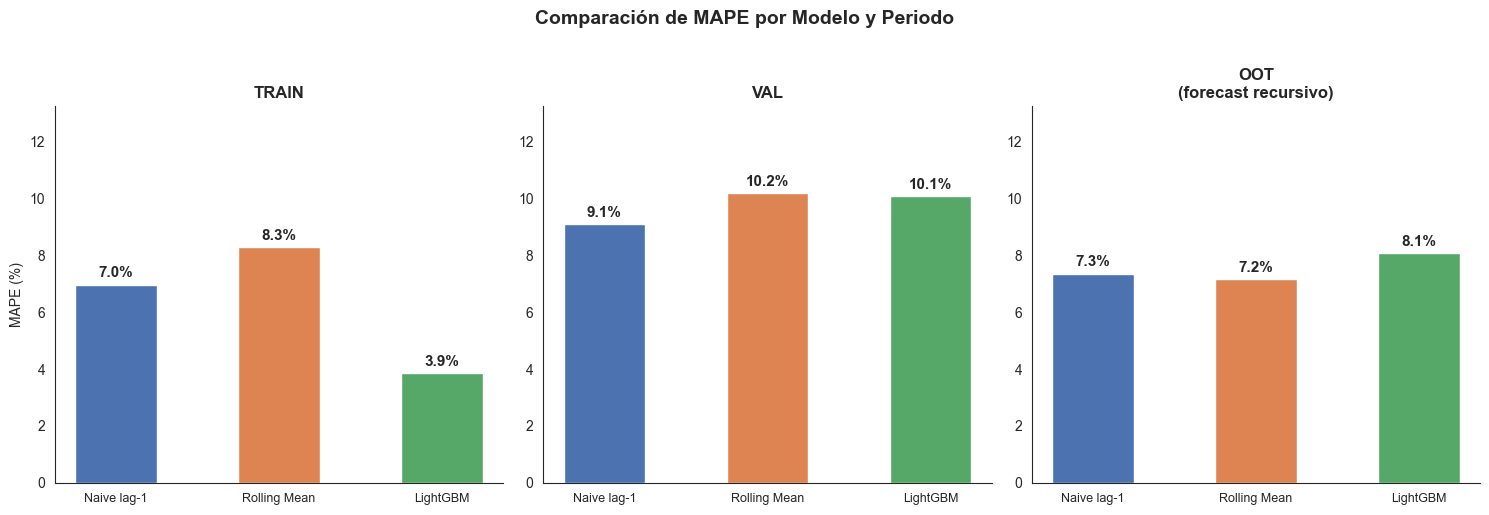

In [ ]:
splits_label = ['train', 'val', 'oot (recursivo)']
modelos      = ['Naive lag-1', 'Rolling Mean', 'LightGBM']
colores      = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, split in zip(axes, splits_label):
    sub  = res_df[res_df['Split'] == split].reset_index(drop=True)
    bars = ax.bar(sub['Modelo'], sub['MAPE_%'], color=colores, width=0.5, edgecolor='white')
    for bar, val in zip(bars, sub['MAPE_%']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    titulo = 'OOT\n(forecast recursivo)' if 'oot' in split else split.upper()
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylim(0, res_df['MAPE_%'].max() * 1.3)
    ax.set_ylabel('MAPE (%)' if split == 'train' else '')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(False)
    sns.despine(ax=ax)

fig.suptitle('Comparación de MAPE por Modelo y Periodo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**6.2. Feature importance LightGBM**
- El 'gain' mide cuánto reduce el error cada feature al dividir los datos.
- Las features con mayor gain son las más informativas para el modelo.

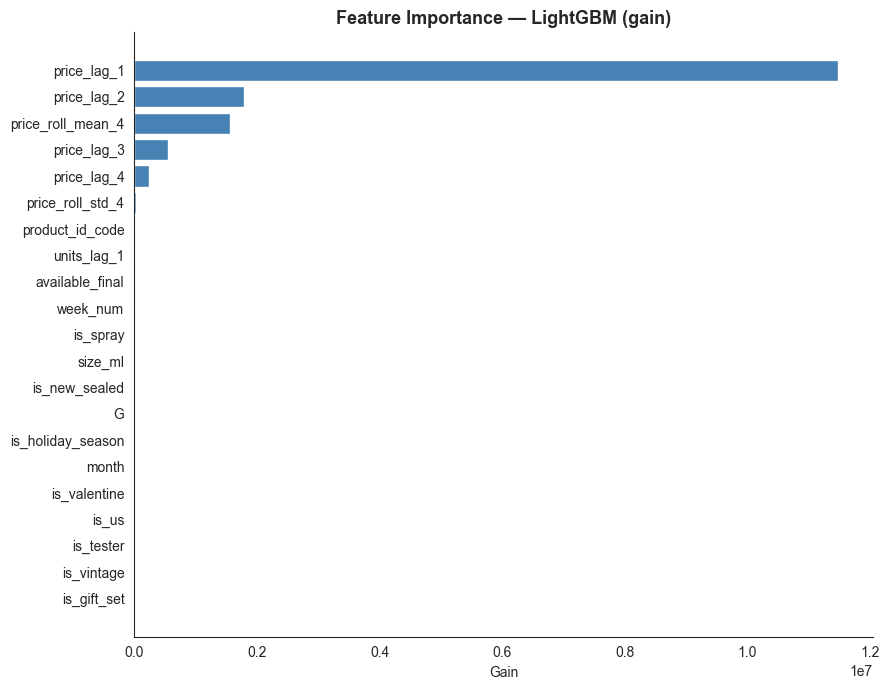

In [91]:
fi = pd.DataFrame({
    'Feature': features,
    'Importance (gain)': model.feature_importance(importance_type='gain')}).sort_values('Importance (gain)', ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(fi['Feature'], fi['Importance (gain)'], color='steelblue')
plt.title('Feature Importance — LightGBM (gain)', fontsize=13, fontweight='bold')
plt.xlabel('Gain')
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

**6.3. Predicciones vs valores reales por producto**
- Seleccionamos 4 productos con precio estable y suficiente historia para visualizar.


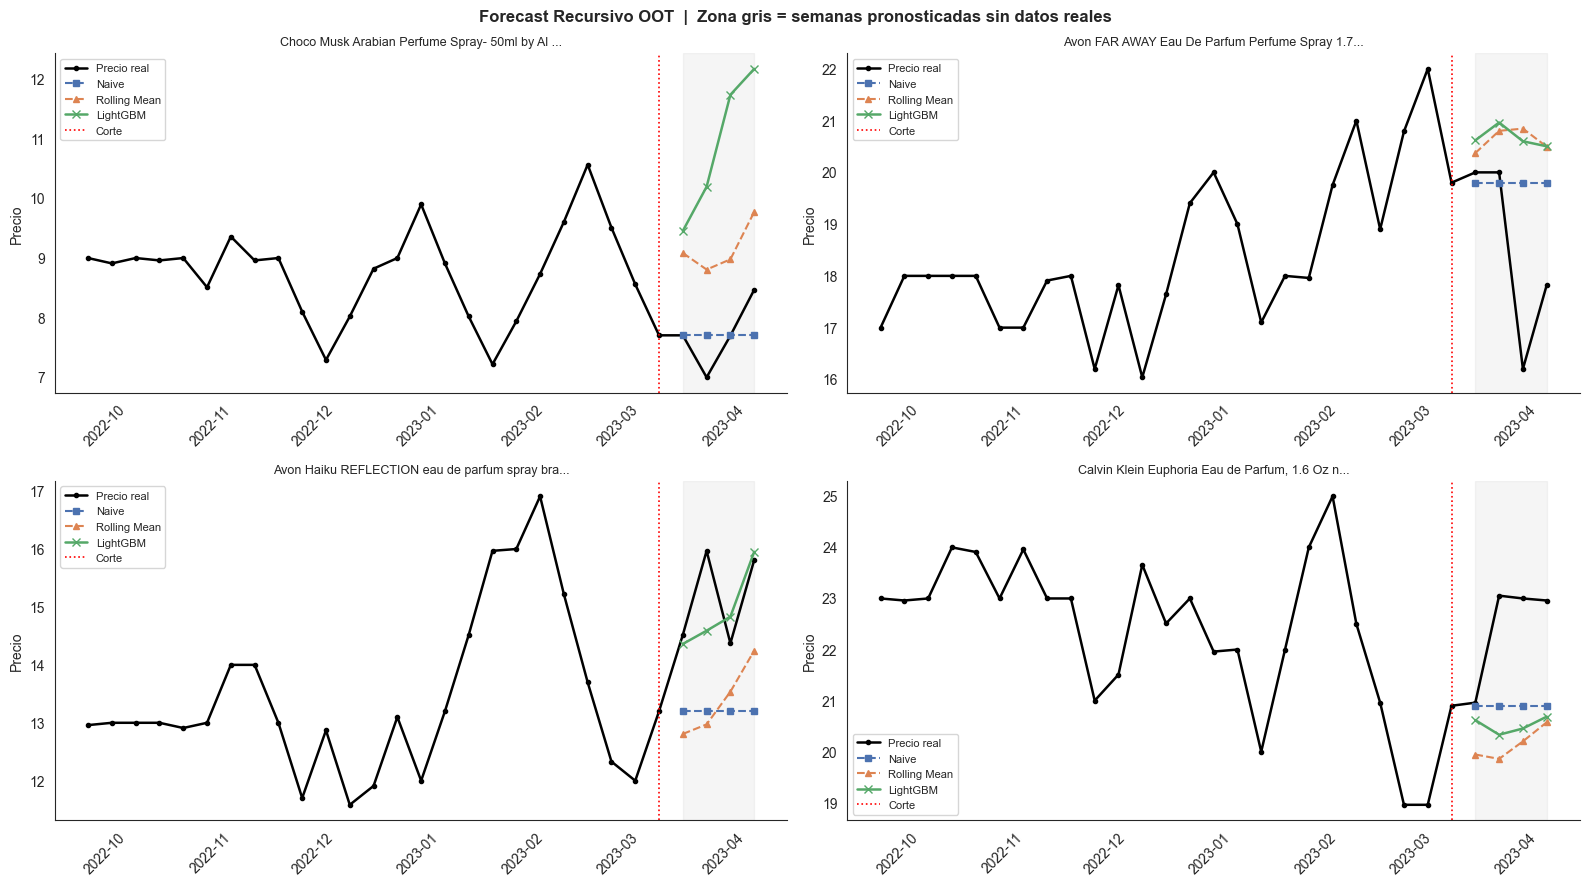

In [92]:
top_prods = (df_uc.groupby('product_id')['price'].count()
             .sort_values(ascending=False).head(4).index.tolist())

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, prod in enumerate(top_prods):
    ax = axes[i]

    # Histórico real
    serie = df_uc[df_uc['product_id'] == prod].sort_values('fecha')
    ax.plot(serie['fecha'], serie['price'], color='black', linewidth=1.8,
            marker='o', markersize=3, label='Precio real')

    # Forecast recursivo OOT
    oot_p = df_oot[df_oot['product_id'] == prod].sort_values('fecha')
    if not oot_p.empty:
        ax.plot(oot_p['fecha'], oot_p['pred_naive'],   color='#4C72B0', linewidth=1.5,
                linestyle='--', marker='s', markersize=5, label='Naive')
        ax.plot(oot_p['fecha'], oot_p['pred_rolling'], color='#DD8452', linewidth=1.5,
                linestyle='--', marker='^', markersize=5, label='Rolling Mean')
        ax.plot(oot_p['fecha'], oot_p['pred_lgbm'],    color='#55A868', linewidth=1.8,
                linestyle='-',  marker='x', markersize=6, label='LightGBM')

    # Línea de corte y zona OOT sombreada
    ax.axvline(fecha_corte, color='red', linestyle=':', linewidth=1.2, label='Corte')
    ax.axvspan(min(fechas_oot), max(fechas_oot), alpha=0.08, color='gray')

    ax.set_title(prod.split('|')[1][:45] + '...', fontsize=9)
    ax.set_ylabel('Precio')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(False)
    sns.despine(ax=ax)

fig.suptitle('Forecast Recursivo OOT  |  Zona gris = semanas pronosticadas sin datos reales',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**6.4. Distribución del error por producto en OOT**
- Calculamos el MAPE individual por producto en OOT para el LightGBM.
- Esto responde: ¿en cuántos productos el modelo tiene precisión Alta/Media/Baja?

In [ ]:
# Calcular APE (Absolute Percentage Error) para cada modelo en OOT
df_oot['ape_naive']   = np.where(df_oot['price_real'] != 0,
    np.abs(df_oot['price_real'] - df_oot['pred_naive']) / df_oot['price_real'] * 100, np.nan)
df_oot['ape_rolling'] = np.where(df_oot['price_real'] != 0,
    np.abs(df_oot['price_real'] - df_oot['pred_rolling']) / df_oot['price_real'] * 100, np.nan)
df_oot['ape_lgbm']    = np.where(df_oot['price_real'] != 0,
    np.abs(df_oot['price_real'] - df_oot['pred_lgbm']) / df_oot['price_real'] * 100, np.nan)

buckets_model = {}
for col, modelo in [('ape_naive','Naive lag-1'), ('ape_rolling','Rolling Mean'), ('ape_lgbm','LightGBM')]:
    mape_prod = df_oot.groupby('product_id')[col].mean().reset_index()
    mape_prod['Precisión'] = pd.cut(
        mape_prod[col],
        bins=[-1, 5, 20, 50, 1000],
        labels=['Alta (≤5%)', 'Media (5-20%)', 'Baja (20-50%)', 'Muy baja (>50%)']
    )
    resumen = mape_prod['Precisión'].value_counts().sort_index().reset_index()
    resumen.columns = ['Bucket', 'Cantidad']
    resumen['% catálogo'] = (resumen['Cantidad'] / resumen['Cantidad'].sum() * 100).round(1)
    buckets_model[modelo] = resumen

print("Distribución de precisión por modelo en OOT:")
print()
for modelo, df in buckets_model.items():
    print(f"{modelo}:")
    print(df.to_string(index=False))
    print()

Distribución de precisión por modelo en OOT:

Naive lag-1:
         Bucket  Cantidad  % catálogo
     Alta (≤5%)        18        25.4
  Media (5-20%)        53        74.6
  Baja (20-50%)         0         0.0
Muy baja (>50%)         0         0.0

Rolling Mean:
         Bucket  Cantidad  % catálogo
     Alta (≤5%)        24        33.8
  Media (5-20%)        47        66.2
  Baja (20-50%)         0         0.0
Muy baja (>50%)         0         0.0

LightGBM:
         Bucket  Cantidad  % catálogo
     Alta (≤5%)        25        35.2
  Media (5-20%)        42        59.2
  Baja (20-50%)         4         5.6
Muy baja (>50%)         0         0.0



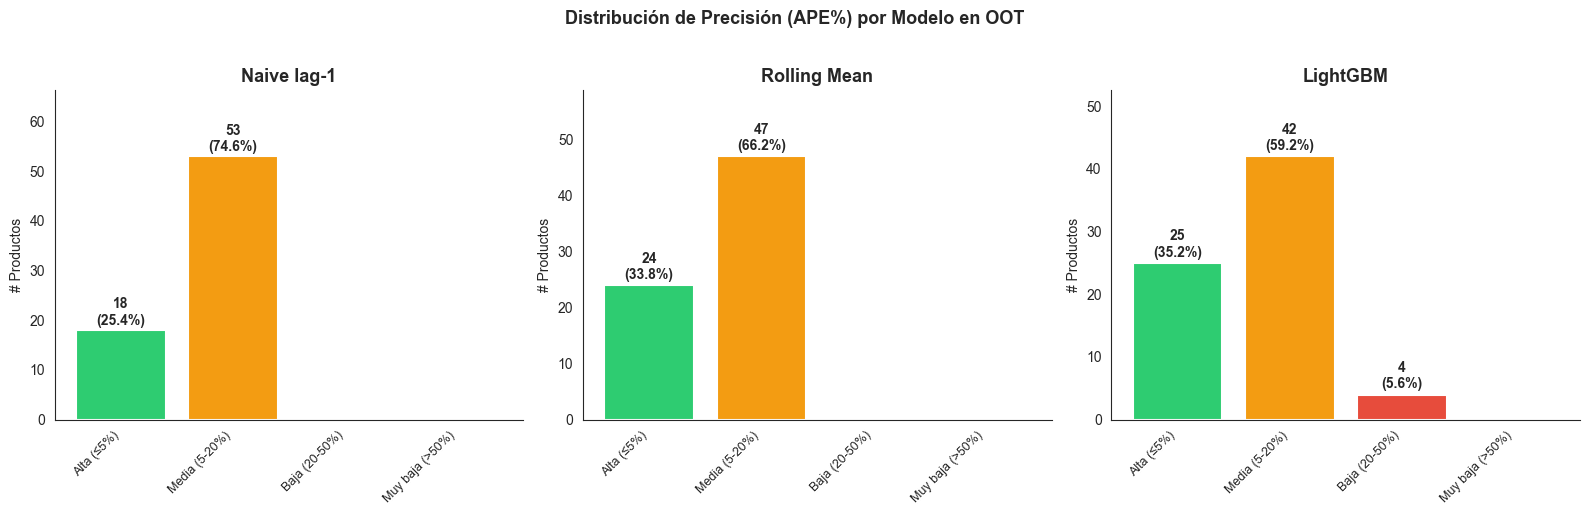

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_bucket = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']  

for ax, (modelo, df) in zip(axes, buckets_model.items()):
    todos_buckets = ['Alta (≤5%)', 'Media (5-20%)', 'Baja (20-50%)', 'Muy baja (>50%)']
    df_completo = pd.DataFrame({'Bucket': todos_buckets})
    df_completo = df_completo.merge(df, on='Bucket', how='left').fillna(0)
    df_completo['Cantidad'] = df_completo['Cantidad'].astype(int)
    df_completo['% catálogo'] = df_completo['% catálogo'].fillna(0)
    
    bars = ax.bar(df_completo['Bucket'], df_completo['Cantidad'], 
                   color=colores_bucket, edgecolor='white', linewidth=1.5)
    
    # Añadir etiquetas con cantidad y porcentaje
    for bar, cant, pct in zip(bars, df_completo['Cantidad'], df_completo['% catálogo']):
        if cant > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{int(cant)}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(modelo, fontsize=13, fontweight='bold')
    ax.set_ylabel('# Productos')
    ax.set_ylim(0, max([df_completo['Cantidad'].max() for df in buckets_model.values()]) * 1.25)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(False)
    ax.set_xticklabels(df_completo['Bucket'], rotation=45, ha='right')
    sns.despine(ax=ax)

fig.suptitle('Distribución de Precisión (APE%) por Modelo en OOT',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **7. Conclusiones Business Case**

**Respuesta al enunciado**

> *"Construye un modelo capaz de pronosticar la evolución del precio en las próximas semanas y señalar tendencias que ayuden a tomar decisiones de inventario y planificación comercial."*

Se construyó un sistema de forecasting de precios para **71 productos EdP 50ml** con horizonte de **4 semanas**, usando un esquema recursivo que no accede a ningún precio futuro real.

---

**Resultados OOT — forecast recursivo a 4 semanas**

| Modelo | MAPE | MAE ($) |
|---|---|---|
| Naive lag-1 | 7.35% | 3.38 |
| **Rolling Mean** | **7.17%** | **3.26** |
| LightGBM | 9.08% | 3.86 |

- El **Rolling Mean es el mejor modelo en OOT**. Esto se justifica a que **los precios de EdP son muy estables semana a semana y el promedio reciente es la señal más robusta a ese horizonte**. 
- El **LightGBM** sobresale en train (MAPE ~3.85%) porque captura patrones por producto, pero en el horizonte de 4 semanas el error recursivo se acumula.

---

**Hallazgos para el negocio**

1. **Precios rígidos a corto plazo (teoría económica)** Cualquier modelo alcanza ~7% MAPE. Más del 95% del catálogo cae en precisión Alta o Media, suficiente para anclar decisiones de inventario con buffer controlado.
2. **Driver principal: el precio reciente.** El `price_lag_1` concentra más del 90% del gain del modelo. Calendario (temporada navideña, San Valentín) y categoría de marca aportan señal secundaria.
3. **Tendencia observada:** ligera presión a la baja de enero a marzo, con recuperación en abril. Recomendación: concentrar reposición de inventario en Q4, reducir exposición en Q1.

---

**Pasos seguidos / excluidos**

- Done: Limpieza profunda de los errores de medición.
- Done: Validación temporal estricta. OOT evaluado con forecast recursivo sin ver datos futuros.
- Done: Comparación contra baselines fuertes (Naive y Rolling Mean).
- Not **ARIMA/Prophet por producto**: 29 semanas por serie es insuficiente; el modelo global cross-section aprovecha las similitudes entre productos y es más eficiente.
- Not **Deep learning (LSTM)**: riesgo alto de overfit con tan pocos datos.

---

**Próximos pasos**

1. **Intervalos de confianza**: LightGBM con `objective='quantile'` para entregar bandas q10/q90.
2. **Más historia** (≥1 año): permite aprender estacionalidad real y mejorar el OOT recursivo.
3. **Variables externas**: tipo de cambio, índice de precios, eventos promocionales del marketplace.